In [ ]:
!pip install qiskit qiskit-aer qiskit-ibm-runtime
!pip install qiskit-experiments

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram

from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel

In [ ]:
# Load the Qiskit Runtime service
from qiskit_ibm_runtime import QiskitRuntimeService

# Optional: configure IBM Quantum
QiskitRuntimeService.save_account(
token="aRTLyP1k6UgBnjO4odaf7YQyUaUXBuMyFIqyXUzCfm2r", # Use the 44-character API_KEY you created and saved from the IBM Quantum Platform Home dashboard
instance="crn:v1:bluemix:public:quantum-computing:us-east:a/7ab57dc5f47e4226aa46a9c34f1024a5:5728c689-85e8-4575-9b2f-349844d99a48::", # Optional: Use the CRN you created and saved from the IBM Quantum Platform Home dashboard
channel="ibm_cloud", # Optional: Use "ibm_quantum" for public access or "ibm_quantum_private" for private access
overwrite=True
)
service = QiskitRuntimeService(channel="ibm_cloud")
print(service.backends())  # list available backends

# Example to select a backend (modify as needed)
backend = service.backend("ibm_torino")  # or any other available backend
sim_backend = AerSimulator()

[<IBMBackend('ibm_fez')>, <IBMBackend('ibm_torino')>, <IBMBackend('ibm_marrakesh')>]


In [ ]:
noise_model = NoiseModel.from_backend(backend)

basis_gates = noise_model.basis_gates
coupling_map = backend.configuration().coupling_map

In [ ]:
sim_torino = AerSimulator(
    noise_model=noise_model,
    basis_gates=basis_gates,
    coupling_map=coupling_map
)

In [ ]:
qc = QuantumCircuit(2,2)

qc.h(0)
qc.cx(0,1)

qc.measure([0,1],[0,1])

qc.draw()

┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1

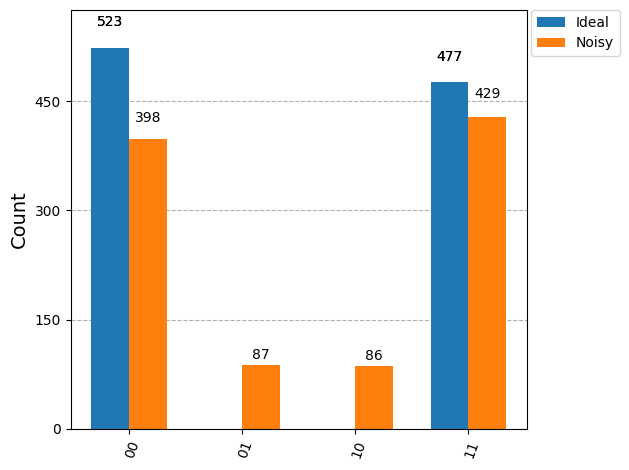

In [ ]:
ideal_sim = AerSimulator()

result_ideal = ideal_sim.run(qc, shots=1000).result()
counts_ideal = result_ideal.get_counts()

result_noisy = sim_torino.run(qc, shots=1000).result()
counts_noisy = result_noisy.get_counts()

plot_histogram([counts_ideal, counts_noisy], legend=["Ideal", "Noisy"])

In [ ]:
from qiskit_experiments.library import LocalReadoutError
from qiskit_experiments.framework import ExperimentData

# Select qubits used in circuit
qubits = [0,1]

# Create readout calibration experiment
exp = LocalReadoutError(qubits)

# Run experiment on noisy simulator
exp_data = exp.run(sim_torino, shots=2000)
exp_data.block_for_results()

# Extract mitigation object
mitigator = exp_data.analysis_results("Local Readout Mitigator").value

/tmp/ipykernel_34921/3947716055.py:15: DeprecationWarning: Leaving `dataframe` unset or setting it to `False` for `ExperimentData.analysis_results` is deprecated as of qiskit-experiments 0.9.0. Future releases may change the default to `True` and remove the option to set the value to `False`.
  mitigator = exp_data.analysis_results("Local Readout Mitigator").value


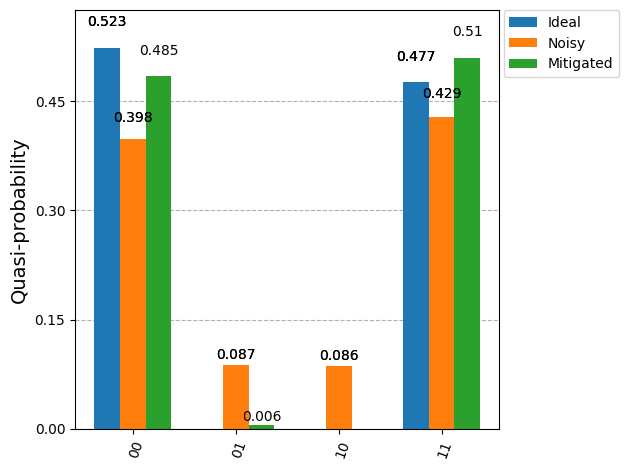

In [ ]:
from qiskit.result import Counts

quasi = mitigator.quasi_probabilities(counts_noisy)
mitigated_counts_raw = quasi.nearest_probability_distribution()
mitigated_counts = {format(k, '02b'): float(v) for k, v in mitigated_counts_raw.items()}

plot_histogram(
    [counts_ideal, counts_noisy, mitigated_counts],
    legend=["Ideal","Noisy","Mitigated"]
)

In [ ]:
def bell_fidelity(counts):

    shots = sum(counts.values())

    p00 = counts.get('00',0)/shots
    p11 = counts.get('11',0)/shots

    fidelity = p00 + p11

    return fidelity, {'00':p00, '01':counts.get('01',0)/shots,
                      '10':counts.get('10',0)/shots,
                      '11':p11}

Ideal Fidelity: 1.0
Noisy Fidelity: 0.827
Mitigated Fidelity: 0.9943733142135274
